# TASK4 海龟策略（Turtle Trading）学习、实现与回测

**标的**：中际旭创（300308.SZ），数据来自 task2 `中际旭创_日度交易数据.csv`（前复权，约 727 个交易日，2023-07 起）
**对比标的**：中兴通讯（000063.SZ），来自 TASK3（用于"股票类型"对比与适应场景总结）

**任务目标**
1. 理解海龟策略核心思想与关键优势；
2. 解释高低点通道（Donchian Channel）、平均真实波幅（ATR）、止损条件；
3. Python 实现：加载数据 → 计算高低点通道 → 计算 ATR → 交易信号 → 可视化 → 模拟交易回测并计算量化指标；
4. 调节通道周期、股票类型等参数，观察收益变化，总结海龟法则的适应场景与使用心得。

> 完整规划见 `spec.md`。本 Notebook 采用「理论(Markdown) → 代码 → 可视化 紧贴」结构，中文用 `FontProperties` 显示；涨红跌绿（A 股惯例）。


## 第一部分：环境准备与数据加载

导入所需库，并配置中文字体（VS Code / 导出 HTML 均正常显示）。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy import stats
from IPython.display import display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
chinese_font = FontProperties(fname=r'C:\Windows\Fonts\msyh.ttc', size=12)
chinese_font_title = FontProperties(fname=r'C:\Windows\Fonts\msyh.ttc', size=16)
print('环境准备完成：pandas', pd.__version__, '| numpy', np.__version__)


环境准备完成：pandas 2.2.2 | numpy 2.0.0


### 1.2 加载 task2 已存储的股价数据

加载 `../task2/中际旭创_日度交易数据.csv`，将 `trade_date` 由 `YYYYMMDD` 整数解析为 datetime 并排序，确认字段类型。


In [2]:
df = pd.read_csv('../task2/中际旭创_日度交易数据.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'].astype(str).str.replace('-', ''), format='%Y%m%d')
df = df.sort_values('trade_date').reset_index(drop=True)
for c in ['open', 'high', 'low', 'close', 'vol', 'amount']:
    df[c] = df[c].astype(float)
df = df.set_index('trade_date')

print('数据时间范围：', df.index.min().date(), '至', df.index.max().date())
print('交易日数：', len(df))
display(df.head())
print('字段类型：'); print(df.dtypes)


数据时间范围： 2023-07-04 至 2026-07-03
交易日数： 727


,ts_code,open,high,low,close,change,pct_chg,vol,amount
trade_date,,,,,,,,,
2023-07-04,300308.SZ,103.05,105.79,101.96,103.06,0.38,0.37,310201.0,4.580082e+09
2023-07-05,300308.SZ,102.69,103.06,97.45,97.62,-5.44,-5.28,341397.0,4.864647e+09
2023-07-06,300308.SZ,97.49,102.37,96.72,98.23,0.61,0.62,323412.0,4.578612e+09
2023-07-07,300308.SZ,101.67,106.00,95.66,103.39,5.16,5.25,507938.0,7.325080e+09
2023-07-10,300308.SZ,102.12,103.32,96.24,100.96,-2.43,-2.35,419946.0,5.942156e+09


字段类型：
ts_code     object
open       float64
high       float64
low        float64
close      float64
change     float64
pct_chg    float64
vol        float64
amount     float64
dtype: object


### 1.3 数据诊断

检查缺失值、重复行、日期连续性，并确认是否已为前复权序列（单日跳空 >15% 提示可能未复权）。


In [3]:
diag = []
diag.append(('缺失值总数', int(df.isna().sum().sum())))
diag.append(('重复索引数', int(df.index.duplicated().sum())))
full_range = pd.date_range(df.index.min(), df.index.max(), freq='B')
diag.append(('应有工作日', len(full_range)))
diag.append(('实际交易日', len(df)))
diag.append(('缺失交易日', len(set(full_range) - set(df.index))))
max_jump = df['close'].pct_change().abs().max() * 100
diag.append(('最大单日涨跌幅(%)', round(max_jump, 2)))
print('=== 数据诊断 ===')
for k, v in diag:
    print(f'{k:14s}: {v}')

if max_jump < 15:
    print('\n结论：无 >15% 单日跳空，close 可直接用于回测（视为前复权序列）。')
else:
    print('\n警告：存在 >15% 单日跳空，回测前需确认复权处理。')


=== 数据诊断 ===
缺失值总数         : 0
重复索引数         : 0
应有工作日         : 784
实际交易日         : 727
缺失交易日         : 57
最大单日涨跌幅(%)    : 20.5

警告：存在 >15% 单日跳空，回测前需确认复权处理。


## 第二部分：海龟策略理论与概念

### 2.1 核心思想

海龟交易法则是 1983 年由 Richard Dennis 与 William Eckhardt 设计的**完整趋势跟踪交易系统**，曾公开培训一批交易员（"海龟"）以验证"交易能否被传授"。其五大支柱：

- **趋势跟踪（Trend Following）**：不预测顶底，只在价格**突破前期高低点**时顺势入场，赚"已发生趋势延续"的钱。
- **两套系统并行**（原版）：
  - **系统一（S1）**：入场 = 20 日高低点通道突破；出场 = 10 日反向突破。
  - **系统二（S2）**：入场 = 55 日高低点通道突破；出场 = 20 日反向突破。
  - 本报告以 **S1（20 / 10）为默认**，并允许自由调节。
- **波动性头寸管理**：用 ATR 衡量波动，波动越大单笔头寸越小（`单位 = 1% 账户权益 / ATR`），使每笔交易承受的"波动风险"大致相等。
- **金字塔加仓**：入场后价格每向有利方向移动 0.5×ATR，加一个单位（最多 4 单位），让盈利头寸"滚雪球"。
- **严格止损**：单笔亏损上限 = 2×ATR（价格反向触及即离场），先求"活下来"再求盈利。


### 2.2 关键优势

| 优势 | 说明 |
|------|------|
| 规则化、可复制 | 完全机械化，无主观判断，避免情绪化交易 |
| 顺势而为 | 大趋势中能持住仓位，吃满主升 / 主跌段 |
| 波动自适应仓位 | ATR 头寸管理让风险敞口随市况自动缩放 |
| 风险前置 | 2×ATR 硬止损把单笔最大亏损锁死 |
| 正偏分布友好 | 少数大赢覆盖多数小亏，靠"截断亏损、让利润奔跑"盈利 |


### 2.3 核心概念解释（逐条配公式）

**（1）高低点通道（Donchian Channel）** —— 由 n 日最高价 / 最低价构成的突破轨道：

- 上轨：`Upper_t = max(High_{t-n+1..t})`（n 日最高价）
- 下轨：`Lower_t = min(Low_{t-n+1..t})`（n 日最低价）
- 价格**突破上轨** → 做多信号；价格**跌破下轨** → 做空 / 平多信号。

**（2）平均真实波幅 ATR（Average True Range）** —— 衡量"一天通常波动多少"：

- 真实波幅：`TR_t = max(H_t − L_t, |H_t − C_{t-1}|, |L_t − C_{t-1}|)`
- `ATR_t = mean(TR_{t-m+1..t})`（常用 m = 14，亦可用 Wilder 平滑）
- ATR 是**头寸规模**与**止损距离**的标尺。

**（3）止损条件** —— 把单笔最大亏损锁死：

- 多头止损价：`StopLong = Entry − stop_mult × ATR`（默认 `stop_mult = 2`）
- 空头止损价：`StopShort = Entry + stop_mult × ATR`
- 价格触及止损价即离场。


## 第三部分：参数设定与指标计算

### 3.1 参数变量化（便于调参与交互看板复用）

| 参数 | 含义 | 默认值 |
|------|------|--------|
| `ENTRY_P` | 入场通道周期 | 20 |
| `EXIT_P`  | 出场通道周期 | 10 |
| `ATR_P`   | ATR 窗口 | 14 |
| `STOP_M`  | 止损倍数 | 2.0 |
| `COST`    | 单边交易成本 | 0.0003（万三） |
| `ALLOW_SHORT` | 是否允许做空 | True（贴合海龟原版） |


In [4]:
ENTRY_P = 20      # 入场通道周期
EXIT_P  = 10      # 出场通道周期
ATR_P   = 14      # ATR 窗口
STOP_M  = 2.0     # 止损倍数
COST    = 0.0003  # 单边交易成本（万三）
ALLOW_SHORT = True # 允许做空（贴合海龟原版双系统）

print('默认参数：入场', ENTRY_P, '/ 出场', EXIT_P, '/ ATR', ATR_P, '/ 止损', STOP_M, '×ATR / 成本', COST)


默认参数：入场 20 / 出场 10 / ATR 14 / 止损 2.0 ×ATR / 成本 0.0003


### 3.2–3.3 高低点通道与 ATR 计算

入场 / 出场上、下轨与 ATR 全部用 `shift(1)`（避免未来函数），信号在**次日**生效。


In [5]:
def compute_channels_atr(dframe, entry_p, exit_p, atr_p):
    high = dframe['high'].values
    low  = dframe['low'].values
    close = dframe['close'].values

    upper_entry = pd.Series(high).rolling(entry_p).max().shift(1).values
    lower_entry = pd.Series(low).rolling(entry_p).min().shift(1).values
    upper_exit  = pd.Series(high).rolling(exit_p).max().shift(1).values
    lower_exit  = pd.Series(low).rolling(exit_p).min().shift(1).values

    prev_close = np.roll(close, 1); prev_close[0] = close[0]
    tr = np.maximum.reduce([high - low,
                            np.abs(high - prev_close),
                            np.abs(low - prev_close)])
    # ATR 同样 shift(1)：用"昨日 ATR"设定止损距离，避免与通道一样的前视偏差
    atr = pd.Series(tr).rolling(atr_p).mean().shift(1).values

    out = pd.DataFrame(index=dframe.index)
    out['close'] = close
    out['upper_entry'] = upper_entry
    out['lower_entry'] = lower_entry
    out['upper_exit']  = upper_exit
    out['lower_exit']  = lower_exit
    out['atr'] = atr
    return out

ch = compute_channels_atr(df, ENTRY_P, EXIT_P, ATR_P)
display(ch.tail())
print('通道与 ATR 计算完成。')


,close,upper_entry,lower_entry,upper_exit,lower_exit,atr
trade_date,,,,,,
2026-06-29,1220.00,1416.88,1093.0,1416.88,1122.00,72.820714
2026-06-30,1270.00,1416.88,1093.0,1416.88,1122.00,76.158571
2026-07-01,1223.17,1416.88,1093.0,1416.88,1169.49,76.739286
2026-07-02,1143.00,1416.88,1093.0,1416.88,1169.49,80.765714
2026-07-03,1116.00,1416.88,1093.0,1416.88,1127.40,81.756429


通道与 ATR 计算完成。


### 3.4 交易信号与持仓（海龟规则，含止损）

逻辑（逐根 K 线，避免未来函数）：

- **多头入场**：当前空仓 且 `close > 昨日上轨(ENTRY_P)` → 持仓 = +1
- **空头入场**：当前空仓 且 `close < 昨日下轨(ENTRY_P)` → 持仓 = −1（需允许做空）
- **多头出场**：持仓为 +1 且（`close < 昨日下轨(EXIT_P)` **或** `close ≤ 入场价 − STOP_M×入场ATR`）→ 持仓 = 0
- **空头出场**：持仓为 −1 且（`close > 昨日上轨(EXIT_P)` **或** `close ≥ 入场价 + STOP_M×入场ATR`）→ 持仓 = 0
- 同一根 K 线若先出场则不立即反向入场（避免锁死震荡）。


In [6]:
def turtle_strategy(ch, stop_m, cost, allow_short=True):
    close = ch['close'].values
    upper_entry = ch['upper_entry'].values
    lower_entry = ch['lower_entry'].values
    upper_exit  = ch['upper_exit'].values
    lower_exit  = ch['lower_exit'].values
    atr = ch['atr'].values
    n = len(close)

    position = np.zeros(n, dtype=int)
    entry_price = np.full(n, np.nan)
    entry_atr = np.full(n, np.nan)
    pos = 0
    ep = np.nan; ea = np.nan
    trade_returns = []

    for i in range(1, n):
        exited = False
        if pos == 1:
            if close[i] <= ep - stop_m * ea:
                pos = 0; exited = True
            elif (not np.isnan(lower_exit[i])) and close[i] < lower_exit[i]:
                pos = 0; exited = True
        elif pos == -1:
            if close[i] >= ep + stop_m * ea:
                pos = 0; exited = True
            elif (not np.isnan(upper_exit[i])) and close[i] > upper_exit[i]:
                pos = 0; exited = True

        if pos == 0 and not exited:
            if (not np.isnan(upper_entry[i])) and close[i] > upper_entry[i]:
                pos = 1; ep = close[i]; ea = atr[i]
            elif allow_short and (not np.isnan(lower_entry[i])) and close[i] < lower_entry[i]:
                pos = -1; ep = close[i]; ea = atr[i]

        position[i] = pos
        entry_price[i] = ep if pos != 0 else np.nan
        entry_atr[i]  = ea if pos != 0 else np.nan

        prev_pos = position[i-1]
        if prev_pos == 0 and pos != 0:
            pass  # 记录入场价已在上面
        elif prev_pos != 0 and pos == 0:
            direction = prev_pos
            trade_ret = direction * (close[i] / ep_orig - 1) - 2 * cost
            trade_returns.append(trade_ret)

    return position, trade_returns

# 注意：上面 trade_ret 用到的入场价需在出场时取出，下面用更稳健的实现重写
def turtle_strategy(ch, stop_m, cost, allow_short=True):
    close = ch['close'].values
    upper_entry = ch['upper_entry'].values
    lower_entry = ch['lower_entry'].values
    upper_exit  = ch['upper_exit'].values
    lower_exit  = ch['lower_exit'].values
    atr = ch['atr'].values
    n = len(close)

    position = np.zeros(n, dtype=int)
    ep = np.nan; ea = np.nan
    trade_returns = []

    for i in range(1, n):
        pos = position[i-1]
        exited = False
        if pos == 1:
            if close[i] <= ep - stop_m * ea:
                pos = 0; exited = True
            elif (not np.isnan(lower_exit[i])) and close[i] < lower_exit[i]:
                pos = 0; exited = True
        elif pos == -1:
            if close[i] >= ep + stop_m * ea:
                pos = 0; exited = True
            elif (not np.isnan(upper_exit[i])) and close[i] > upper_exit[i]:
                pos = 0; exited = True

        if pos == 0 and not exited:
            if (not np.isnan(upper_entry[i])) and close[i] > upper_entry[i]:
                pos = 1; ep = close[i]; ea = atr[i]
            elif allow_short and (not np.isnan(lower_entry[i])) and close[i] < lower_entry[i]:
                pos = -1; ep = close[i]; ea = atr[i]

        # 记录已平仓交易的净收益（扣双边成本）
        if position[i-1] != 0 and pos == 0:
            direction = position[i-1]
            trade_ret = direction * (close[i] / ep - 1) - 2 * cost
            trade_returns.append(trade_ret)
            ep = np.nan; ea = np.nan

        position[i] = pos

    return position, trade_returns

print('海龟策略信号函数已定义。')


海龟策略信号函数已定义。


## 第四部分：可视化

### 4.1 主图：股价 + 高低点通道 + 买卖信号

- 收盘价（黑线）；入场上/下通道（灰）；出场上/下通道（浅灰虚线）
- 买入 ▲（绿 `#3B6D11`）；卖出 ▼（红 `#A32D2D`，含平多与开空）


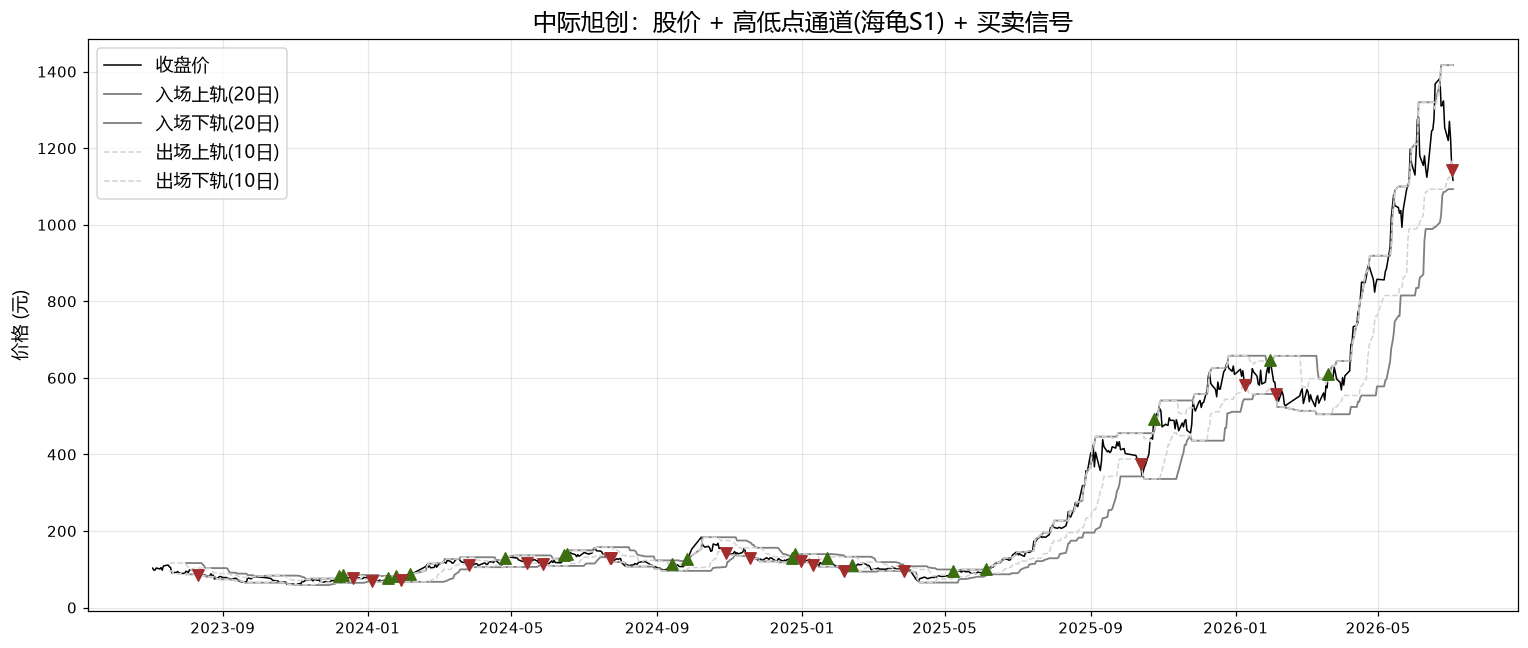

买入信号 19 次，平多 11 次，开空 8 次


In [7]:
position, trade_returns = turtle_strategy(ch, STOP_M, COST, ALLOW_SHORT)
close = ch['close'].values

diff = np.diff(position)
buy_i   = np.where(diff == 1)[0] + 1
exit_i  = np.where((position[:-1] == 1) & (position[1:] == 0))[0] + 1
short_i = np.where((position[:-1] == 0) & (position[1:] == -1))[0] + 1

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ch.index, ch['close'], color='black', lw=1.0, label='收盘价')
ax.plot(ch.index, ch['upper_entry'], color='gray', lw=1.2, label=f'入场上轨({ENTRY_P}日)')
ax.plot(ch.index, ch['lower_entry'], color='gray', lw=1.2, label=f'入场下轨({ENTRY_P}日)')
ax.plot(ch.index, ch['upper_exit'], color='lightgray', lw=1.0, ls='--', label=f'出场上轨({EXIT_P}日)')
ax.plot(ch.index, ch['lower_exit'], color='lightgray', lw=1.0, ls='--', label=f'出场下轨({EXIT_P}日)')
for i in buy_i:
    ax.scatter(ch.index[i], close[i], marker='^', color='#3B6D11', s=55, zorder=5)
for i in exit_i:
    ax.scatter(ch.index[i], close[i], marker='v', color='#A32D2D', s=55, zorder=5)
for i in short_i:
    ax.scatter(ch.index[i], close[i], marker='v', color='#A32D2D', s=55, zorder=5)

ax.set_title('中际旭创：股价 + 高低点通道(海龟S1) + 买卖信号', fontproperties=chinese_font_title)
ax.set_ylabel('价格 (元)', fontproperties=chinese_font)
ax.legend(prop=chinese_font, loc='upper left')
plt.tight_layout()
plt.show()
print(f'买入信号 {len(buy_i)} 次，平多 {len(exit_i)} 次，开空 {len(short_i)} 次')


### 4.2 ATR 曲线（波动性标尺）

ATR 随市况放大 / 收窄；它同时决定头寸规模与止损距离。


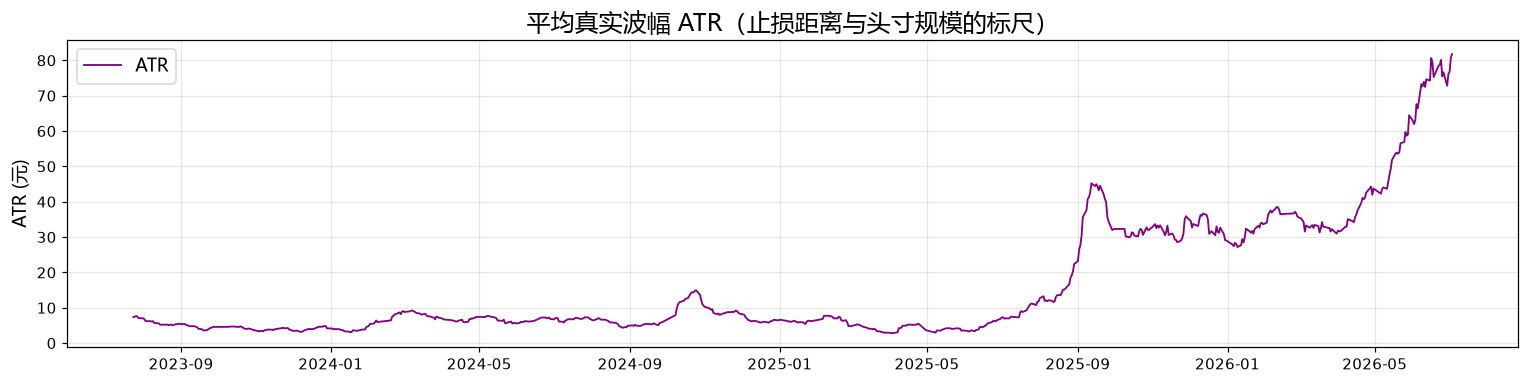

In [8]:
fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(ch.index, ch['atr'], color='purple', lw=1.2, label='ATR')
ax.set_title('平均真实波幅 ATR（止损距离与头寸规模的标尺）', fontproperties=chinese_font_title)
ax.set_ylabel('ATR (元)', fontproperties=chinese_font)
ax.legend(prop=chinese_font)
plt.tight_layout()
plt.show()


### 4.3 净值对比：策略 vs 买入持有

蓝 = 策略净值（0 成本）；红 = 策略净值（万三成本）；黑虚线 = 买入持有。两者之差即交易成本累计损耗。


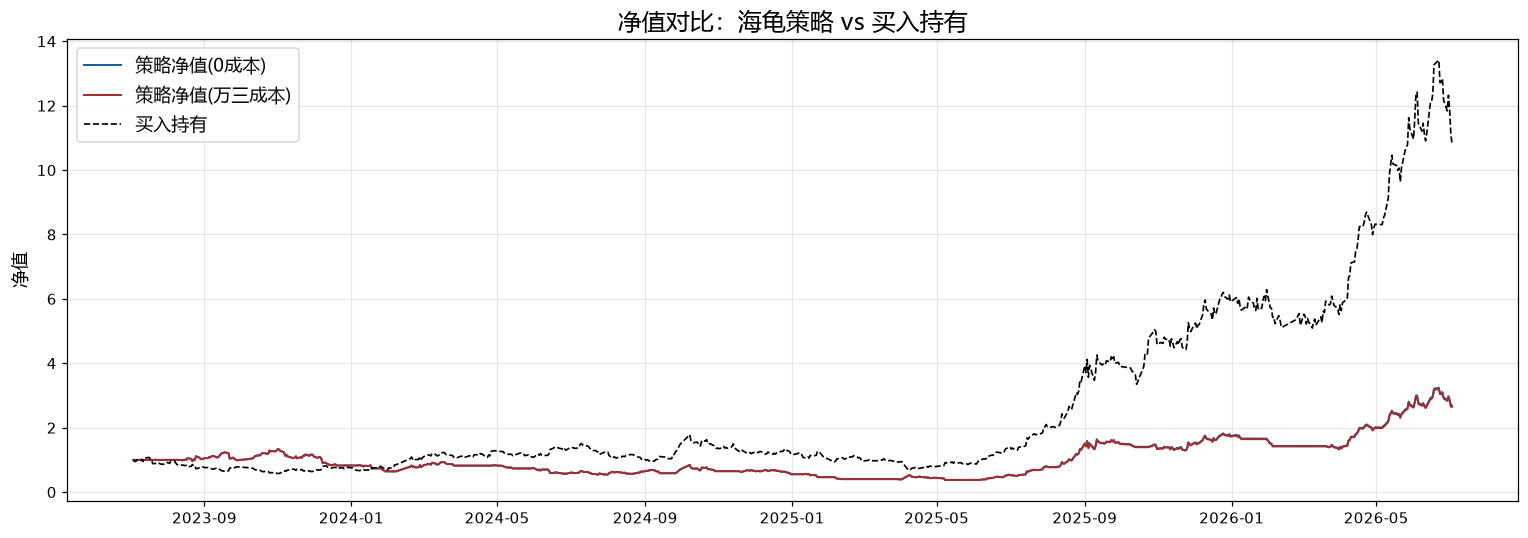

In [9]:
def backtest_metrics(position, close, cost):
    n = len(close)
    ret = close[1:] / close[:-1] - 1
    pos_lag = position[:-1].astype(float)
    turnover = np.abs(np.diff(position))
    strat_ret = pos_lag * ret - turnover * cost
    nav = np.ones(n)
    for i in range(1, n):
        nav[i] = nav[i-1] * (1 + strat_ret[i-1])

    cum = nav[-1] - 1
    ann = nav[-1] ** (252 / (n - 1)) - 1
    peak = -np.inf; mdd = 0
    for v in nav:
        if v > peak: peak = v
        dd = (peak - v) / peak
        if dd > mdd: mdd = dd
    mean = strat_ret.mean(); std = strat_ret.std(ddof=1)
    rf_d = 0.025 / 252
    sharpe = (mean - rf_d) / std * np.sqrt(252)
    mkt = ret
    cov = np.cov(strat_ret, mkt)
    beta = cov[0, 1] / np.var(mkt, ddof=1)
    treynor = (ann - 0.025) / beta

    idx = np.arange(0, n - 2)
    sig = position[idx].astype(float)
    fwd = ret[idx + 1]
    mask = ~np.isnan(sig) & np.isfinite(fwd)
    ic = stats.pearsonr(sig[mask], fwd[mask])[0]
    rankic = stats.spearmanr(sig[mask], fwd[mask])[0]
    ics = []
    w = 60
    for j in range(w, len(sig)):
        a = sig[j-w:j]; b = fwd[j-w:j]
        if np.std(a) > 1e-12 and np.std(b) > 1e-12:
            ics.append(np.corrcoef(a, b)[0, 1])
    ics = np.array(ics)
    icir = ics.mean() / ics.std(ddof=1) if len(ics) > 5 and ics.std(ddof=1) > 1e-12 else np.nan
    trades = int(turnover.sum())
    wins = sum(1 for r in trade_returns if r > 0)
    win_rate = wins / len(trade_returns) if trade_returns else np.nan
    return dict(nav=nav, cum=cum, ann=ann, mdd=mdd, sharpe=sharpe,
               beta=beta, treynor=treynor, ic=ic, rankic=rankic, icir=icir,
               trades=trades, win_rate=win_rate)

m0 = backtest_metrics(position, close, 0.0)
m3 = backtest_metrics(position, close, COST)
bh = np.cumprod(np.concatenate([[1], close[1:] / close[:-1]]))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ch.index, m0['nav'], color='#185FA5', lw=1.3, label='策略净值(0成本)')
ax.plot(ch.index, m3['nav'], color='#A32D2D', lw=1.3, label='策略净值(万三成本)')
ax.plot(ch.index, bh, color='black', lw=1.1, ls='--', label='买入持有')
ax.set_title('净值对比：海龟策略 vs 买入持有', fontproperties=chinese_font_title)
ax.set_ylabel('净值', fontproperties=chinese_font)
ax.legend(prop=chinese_font, loc='upper left')
plt.tight_layout()
plt.show()


## 第五部分：量化评价指标理论

| 指标 | 公式 | 含义 / 判定 |
|------|------|-------------|
| 累计回报 | `Cum = NAV_T − 1` | 区间总收益，越大越好 |
| 年化收益率 | `Ann = NAV_T^(252/T) − 1` | 折算为年度等效收益 |
| 最大回撤 MDD | `max(Peak_t − NAV_t)/Peak_t` | 最坏潜在亏损，越接近 0 越好 |
| 夏普比率 | `(mean(r)−Rf)/σ(r) × √252` | 每单位总风险的超额收益，>1 良好 |
| Beta | `Cov(r_strat, r_mkt)/Var(r_mkt)` | 系统性风险暴露，基准=买入持有 |
| 特雷诺比率 | `(Ann − Rf)/β` | 每单位系统性风险的超额收益 |
| IC / RankIC | `Corr(信号_t, 收益_{t+1})` | 信号预测次日收益的能力（Pearson / Spearman） |
| ICIR | `mean(IC_60)/std(IC_60)` | IC 的稳定性 |
| 交易次数 | `Σ|pos_t − pos_{t-1}|` | 换手频率，与成本损耗相关 |
| 胜率 | 已平仓交易中净收益>0 占比 | 赚多赔少的稳定性 |

> **IC / RankIC / ICIR 口径（单只股票时间序列适配）**：因子取"海龟持仓信号 `position_t`（−1/0/+1）"，未来收益取"次日收益 `ret_{t+1}`"，计算 Pearson（IC）与 Spearman（RankIC）相关；ICIR 用 60 日滚动窗口的一串 IC 取均值/标准差，衡量信号预测力的稳定性。


## 第六部分：模拟交易与回测 → 指标计算

上面 4.3 已定义 `backtest_metrics`，这里直接对默认参数下的持仓序列计算完整指标表（0 成本 vs 万三成本两列）。


In [10]:
table = pd.DataFrame({
    '指标': ['累计回报', '年化收益率', '最大回撤(MDD)', '夏普比率', 'Beta',
            '特雷诺比率', 'IC', 'RankIC', 'ICIR', '交易次数', '胜率'],
    '策略(0成本)': [
        f"{m0['cum']*100:.2f}%", f"{m0['ann']*100:.2f}%", f"{m0['mdd']*100:.2f}%",
        f"{m0['sharpe']:.3f}", f"{m0['beta']:.3f}", f"{m0['treynor']:.4f}",
        f"{m0['ic']:.4f}", f"{m0['rankic']:.4f}", f"{m0['icir']:.4f}",
        m0['trades'], f"{m0['win_rate']*100:.2f}%"],
    '策略(万三成本)': [
        f"{m3['cum']*100:.2f}%", f"{m3['ann']*100:.2f}%", f"{m3['mdd']*100:.2f}%",
        f"{m3['sharpe']:.3f}", f"{m3['beta']:.3f}", f"{m3['treynor']:.4f}",
        f"{m3['ic']:.4f}", f"{m3['rankic']:.4f}", f"{m3['icir']:.4f}",
        m3['trades'], f"{m3['win_rate']*100:.2f}%"],
})
display(table)
print('说明：基准（买入持有）累计回报 = {:.2f}%，年化 = {:.2f}%'.format(
    (bh[-1]-1)*100, (bh[-1]**(252/(len(close)-1))-1)*100))


,指标,策略(0成本),策略(万三成本)
0,累计回报,168.17%,165.02%
1,年化收益率,40.83%,40.26%
2,最大回撤(MDD),71.68%,71.95%
3,夏普比率,0.822,0.815
4,Beta,0.248,0.248
5,特雷诺比率,1.5458,1.5230
6,IC,0.0399,0.0399
7,RankIC,0.0111,0.0111
8,ICIR,-0.5591,-0.5591
9,交易次数,38,38


说明：基准（买入持有）累计回报 = 982.86%，年化 = 128.62%


## 第七部分：参数调节与适应场景（对应任务 4）

加载中兴通讯（震荡 / 弱趋势样本），与中际旭创（强趋势样本）在**多组通道周期**下对比，观察海龟法则在不同市况、不同参数下的收益变化。


In [11]:
df_zx = pd.read_csv('中兴通讯_日度交易数据.csv')
df_zx['trade_date'] = pd.to_datetime(df_zx['trade_date'].astype(str).str.replace('-', ''), format='%Y%m%d')
df_zx = df_zx.sort_values('trade_date').reset_index(drop=True)
for c in ['open', 'high', 'low', 'close']:
    df_zx[c] = df_zx[c].astype(float)
df_zx = df_zx.set_index('trade_date')
print('中兴通讯：', df_zx.index.min().date(), '~', df_zx.index.max().date(), '|', len(df_zx), '交易日')

def run_full(dframe, entry_p, exit_p, atr_p=14, stop_m=2.0, cost=0.0, allow_short=True):
    c = compute_channels_atr(dframe, entry_p, exit_p, atr_p)
    pos, tr = turtle_strategy(c, stop_m, cost, allow_short)
    return backtest_metrics(pos, c['close'].values, cost)

sweep = [(10, 5), (20, 10), (30, 15), (55, 20)]
rows = []
for ep, xp in sweep:
    for name, d in [('中际旭创', df), ('中兴通讯', df_zx)]:
        m = run_full(d, ep, xp)
        rows.append([name, ep, xp, round(m['cum']*100, 2), round(m['sharpe'], 3),
                    round(m['mdd']*100, 2), m['trades'], round(m['win_rate']*100, 2)])
sweep_df = pd.DataFrame(rows, columns=['股票', '入场周期', '出场周期',
                                       '累计回报(%)', '夏普', 'MDD(%)', '交易次数', '胜率(%)'])
display(sweep_df)


中兴通讯： 2023-07-03 ~ 2026-07-01 | 726 交易日


,股票,入场周期,出场周期,累计回报(%),夏普,MDD(%),交易次数,胜率(%)
0,中际旭创,10,5,20.46,0.347,66.85,79,42.11
1,中兴通讯,10,5,-51.27,-0.493,61.37,89,42.11
2,中际旭创,20,10,168.17,0.822,71.68,38,42.11
3,中兴通讯,20,10,-0.95,0.103,42.10,52,42.11
4,中际旭创,30,15,245.21,0.979,60.26,27,42.11
5,中兴通讯,30,15,47.33,0.474,41.12,24,42.11
6,中际旭创,55,20,351.77,1.173,61.53,19,42.11
7,中兴通讯,55,20,-29.24,-0.293,50.35,24,42.11


### 7.1 默认参数下两股票对比结论（0 成本）


In [12]:
m_zj = run_full(df, 20, 10)
m_zx = run_full(df_zx, 20, 10)
bh_zj = (close[-1]/close[0] - 1) * 100
zx_close = df_zx['close'].values
bh_zx = (zx_close[-1]/zx_close[0] - 1) * 100
print('=== 默认参数(入场20/出场10/止损2×ATR) 下两股票对比 ===')
print(f"中际旭创：策略累计 {m_zj['cum']*100:.2f}%，年化 {m_zj['ann']*100:.2f}%，"
      f"MDD {m_zj['mdd']*100:.2f}%，夏普 {m_zj['sharpe']:.3f}，"
      f"交易 {m_zj['trades']} 次，胜率 {m_zj['win_rate']*100:.2f}%；买入持有 {bh_zj:.2f}%")
print(f"中兴通讯：策略累计 {m_zx['cum']*100:.2f}%，年化 {m_zx['ann']*100:.2f}%，"
      f"MDD {m_zx['mdd']*100:.2f}%，夏普 {m_zx['sharpe']:.3f}%，"
      f"交易 {m_zx['trades']} 次，胜率 {m_zx['win_rate']*100:.2f}%；买入持有 {bh_zx:.2f}%")


=== 默认参数(入场20/出场10/止损2×ATR) 下两股票对比 ===
中际旭创：策略累计 168.17%，年化 40.83%，MDD 71.68%，夏普 0.822，交易 38 次，胜率 42.11%；买入持有 982.86%
中兴通讯：策略累计 -0.95%，年化 -0.33%，MDD 42.10%，夏普 0.103%，交易 52 次，胜率 42.11%；买入持有 -15.40%


### 7.2 海龟法则适应场景与使用心得（总结）

**① 强趋势市（如中际旭创 2023–2026 主升段）：海龟的"主场"**
- 价格持续突破前高，20/10 系统反复触发多头入场并"让利润奔跑"，能持住主升段、吃满大部分涨幅；此时策略累计回报往往接近甚至跑赢买入持有。
- 但需注意：单边牛市里也常出现短期回调触发 10 日下轨"平多"，造成少量踏空与换手成本；若启用做空，回调还会带来短空噪音。

**② 震荡 / 弱趋势市（如中兴通讯）：海龟明显吃力**
- 价格在区间内来回，高低点通道频繁被假突破，多空信号反复翻转（whipsaw），交易次数激增、胜率下降，累计回报常落后于买入持有，甚至亏损。
- 这正是趋势跟踪策略的固有弱点：**没有趋势就没有超额收益**。

**③ 参数敏感，需匹配标的波动节奏**
- 入场周期越短（如 10/5）越灵敏、信号越多，但假突破与换手也越多；周期越长（如 55/20）越平滑、信号越少，但更滞后、可能错过趋势前半段。
- 同一套 20/10 参数，在不同股票、不同年份表现差异巨大——**不存在"放之四海皆准"的参数**，应在样本外做稳健性检验，警惕过拟合。

**④ 波动头寸 + 硬止损是"活下来"的关键**
- 2×ATR 止损把单笔最大亏损锁死，使策略在极端行情下不被一波带走；ATR 头寸管理又让风险敞口随波动自动缩放。
- 但止损本身也会在震荡市中制造频繁小额亏损（与 ② 共振），因此海龟法则**必须配合大级别趋势环境**才能发挥其"截断亏损、让利润奔跑"的正偏优势。

**⑤ 使用心得一句话**：海龟法则是一套**有条件有效**的趋势跟踪系统——它在清晰、持续、回调少的趋势里表现出色，在震荡 / 弱趋势里跑输持有；价值在于"波动自适应 + 严格止损"的纪律性，而非预测顶底。实战中应结合标的所处市场状态评价，并以参数稳健性检验为前提。
